# Vocabulary Creation from Amazon Reviews
Build and analyze vocabulary using manual approaches and sklearn's `CountVectorizer`. Store vocabulary for later BOW usage.

## 0. Install Dependencies (run once)

In [1]:
%pip install pandas scikit-learn matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Import Required Libraries

In [2]:
import pandas as pd
import re
import string
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load CSV File

In [3]:
df = pd.read_csv("amazon_reviews_preprocessed_clean.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
df.head(3)

Shape: (100, 5)
Columns: ['review_text', 'rating', 'reviewer_name', 'review_date', 'cleaned_text']



,review_text,rating,reviewer_name,review_date,cleaned_text
0,Ive been using the OnePlus Nord 5 for a few we...,NaN,Anonymous,NaN,using oneplus nord 5 week honestly one best al...
1,Been using it over 2 months now and the experi...,NaN,Anonymous,NaN,using 2 month experience amazing phone smooth ...
2,Decent phone with better build quality and per...,NaN,Anonymous,NaN,decent phone better build quality performance ...


## 3. Text Preprocessing

The CSV already contains a `cleaned_text` column. We apply additional light cleaning (lowercase, remove punctuation/digits) and then tokenize.

In [4]:
# Use cleaned_text column; drop nulls
texts = df["cleaned_text"].dropna().astype(str).tolist()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # remove punctuation and digits
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_texts = [preprocess(t) for t in texts]

# Tokenize
tokenized = [t.split() for t in cleaned_texts]

print(f"Total reviews: {len(cleaned_texts)}")
print(f"Sample tokens (review 0): {tokenized[0][:20]}")

Total reviews: 100
Sample tokens (review 0): ['using', 'oneplus', 'nord', 'week', 'honestly', 'one', 'best', 'allround', 'midrange', 'phone', 'tried', 'long', 'time', 'snapdragon', 'gen', 'delivers', 'incredible', 'speed', 'multitasking', 'gaming']


## 4. Build Vocabulary Manually

Using Python's `collections.Counter` to count every token across all reviews and derive a sorted vocabulary.

In [5]:
# Flatten all tokens into a single list
all_tokens = [token for tokens in tokenized for token in tokens]

# Count frequencies
word_freq = Counter(all_tokens)

# Vocabulary: sorted set of unique words  --> stored for later BOW use
manual_vocab = sorted(word_freq.keys())

# Also store as word-to-index mapping for BOW
manual_word2idx = {word: idx for idx, word in enumerate(manual_vocab)}

print(f"Manual Vocabulary Size : {len(manual_vocab)}")
print(f"Total Tokens (with repeats) : {len(all_tokens)}")
print(f"\nTop 20 Most Frequent Words:")
print("-" * 35)
top20_manual = word_freq.most_common(20)
for rank, (word, freq) in enumerate(top20_manual, 1):
    print(f"  {rank:>2}. {word:<20} {freq}")

Manual Vocabulary Size : 282
Total Tokens (with repeats) : 8638

Top 20 Most Frequent Words:
-----------------------------------
   1. phone                236
   2. camera               203
   3. good                 200
   4. best                 184
   5. use                  151
   6. fast                 136
   7. battery              135
   8. one                  134
   9. nord                 119
  10. performance          119
  11. easily               118
  12. last                 118
  13. day                  118
  14. oneplus              102
  15. charging             100
  16. gaming               99
  17. gen                  84
  18. display              84
  19. price                84
  20. premium              84


## 5. Build Vocabulary Using Sklearn

`CountVectorizer` automatically handles tokenization and builds a term-document matrix. We inspect the resulting vocabulary and compare its size with the manual approach.

In [6]:
vectorizer = CountVectorizer(token_pattern=r"(?u)\b[a-z]{2,}\b")  # words with 2+ letters
X = vectorizer.fit_transform(cleaned_texts)

# Vocabulary dict {word: column_index}  --> stored for later BOW use
sklearn_vocab = vectorizer.vocabulary_
sklearn_vocab_list = sorted(sklearn_vocab.keys())

print(f"Sklearn Vocabulary Size : {len(sklearn_vocab_list)}")
print(f"Document-Term Matrix Shape : {X.shape}")

# Per-word total counts from the matrix
word_totals = X.sum(axis=0).A1                  # dense 1-D array
sklearn_freq = {w: int(word_totals[sklearn_vocab[w]]) for w in sklearn_vocab_list}
top20_sklearn = sorted(sklearn_freq.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"\nTop 20 Most Frequent Words (sklearn):")
print("-" * 35)
for rank, (word, freq) in enumerate(top20_sklearn, 1):
    print(f"  {rank:>2}. {word:<20} {freq}")

Sklearn Vocabulary Size : 276
Document-Term Matrix Shape : (100, 276)

Top 20 Most Frequent Words (sklearn):
-----------------------------------
   1. phone                236
   2. camera               203
   3. good                 200
   4. best                 184
   5. use                  151
   6. fast                 136
   7. battery              135
   8. one                  134
   9. nord                 119
  10. performance          119
  11. day                  118
  12. easily               118
  13. last                 118
  14. oneplus              102
  15. charging             100
  16. gaming               99
  17. display              84
  18. gen                  84
  19. premium              84
  20. price                84


## 6. Store Vocabulary Variables for Later BOW Use

The following variables are now ready for Bag-of-Words:
- `manual_vocab` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ sorted list of unique words (manual)
- `manual_word2idx` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ word ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ index mapping (manual)
- `sklearn_vocab` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ word ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ index mapping (sklearn)
- `vectorizer` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ fitted CountVectorizer (can transform new text directly)
- `X` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ document-term matrix (sklearn)

In [7]:
# Summary of stored variables
print("Stored variables for BOW:")
print(f"  manual_vocab       : list  ({len(manual_vocab)} words)")
print(f"  manual_word2idx    : dict  ({len(manual_word2idx)} entries)")
print(f"  sklearn_vocab      : dict  ({len(sklearn_vocab)} entries)")
print(f"  vectorizer         : fitted CountVectorizer")
print(f"  X (doc-term matrix): {X.shape}")
print(f"  word_freq          : Counter ({len(word_freq)} words)")
print(f"\nSample manual_word2idx entries:")
for w in list(manual_word2idx)[:10]:
    print(f"    '{w}' -> {manual_word2idx[w]}")

Stored variables for BOW:
  manual_vocab       : list  (282 words)
  manual_word2idx    : dict  (282 entries)
  sklearn_vocab      : dict  (276 entries)
  vectorizer         : fitted CountVectorizer
  X (doc-term matrix): (100, 276)
  word_freq          : Counter (282 words)

Sample manual_word2idx entries:
    'acceptable' -> 0
    'affect' -> 1
    'ai' -> 2
    'all' -> 3
    'allround' -> 4
    'almost' -> 5
    'alot' -> 6
    'also' -> 7
    'amazing' -> 8
    'amoled' -> 9


## 7. Analyze Top Frequent Words

Visualize top 20 words from both approaches side-by-side, and plot a Zipf frequency distribution curve.

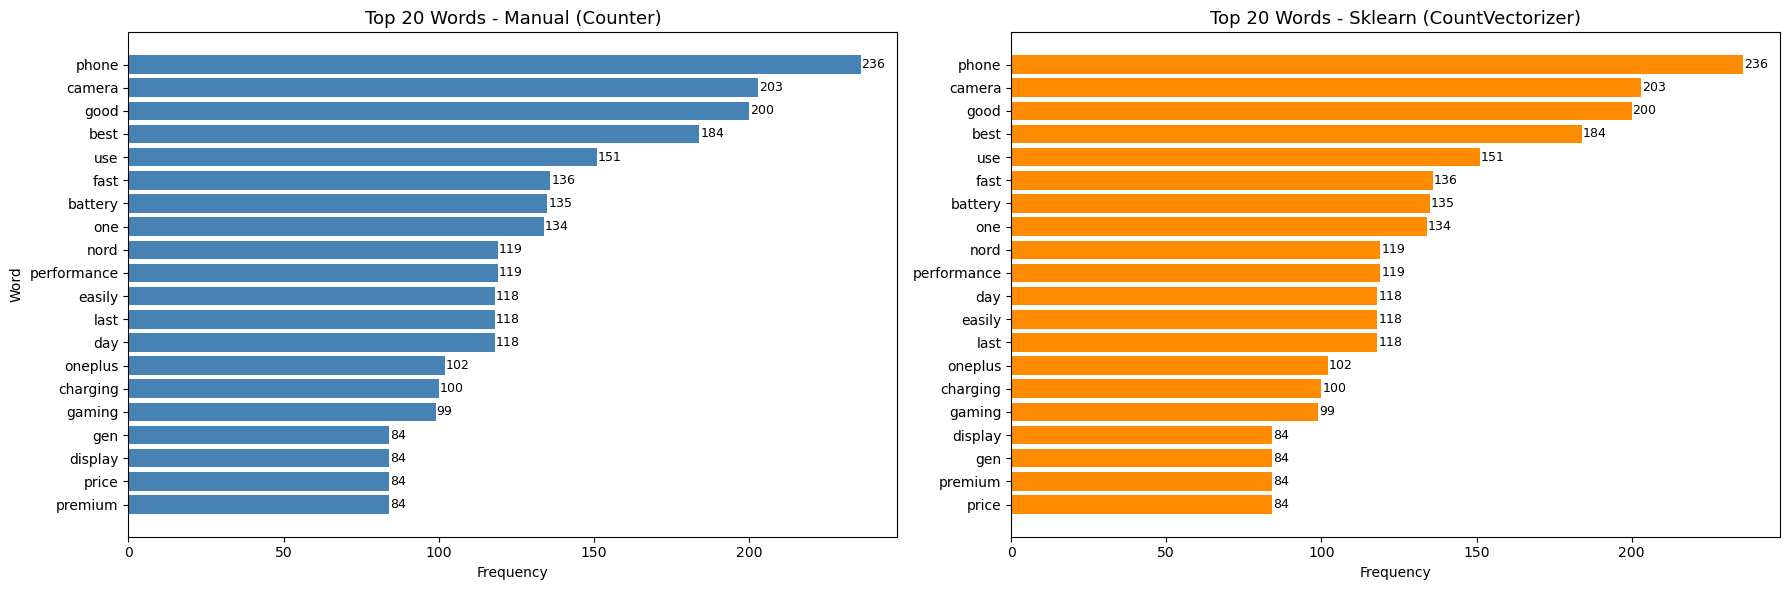

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Manual
m_words  = [w for w, _ in top20_manual]
m_counts = [c for _, c in top20_manual]
axes[0].barh(m_words[::-1], m_counts[::-1], color="steelblue")
axes[0].set_title("Top 20 Words - Manual (Counter)", fontsize=13)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")
for i, v in enumerate(m_counts[::-1]):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

# Sklearn
s_words  = [w for w, _ in top20_sklearn]
s_counts = [int(c) for _, c in top20_sklearn]
axes[1].barh(s_words[::-1], s_counts[::-1], color="darkorange")
axes[1].set_title("Top 20 Words - Sklearn (CountVectorizer)", fontsize=13)
axes[1].set_xlabel("Frequency")
for i, v in enumerate(s_counts[::-1]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

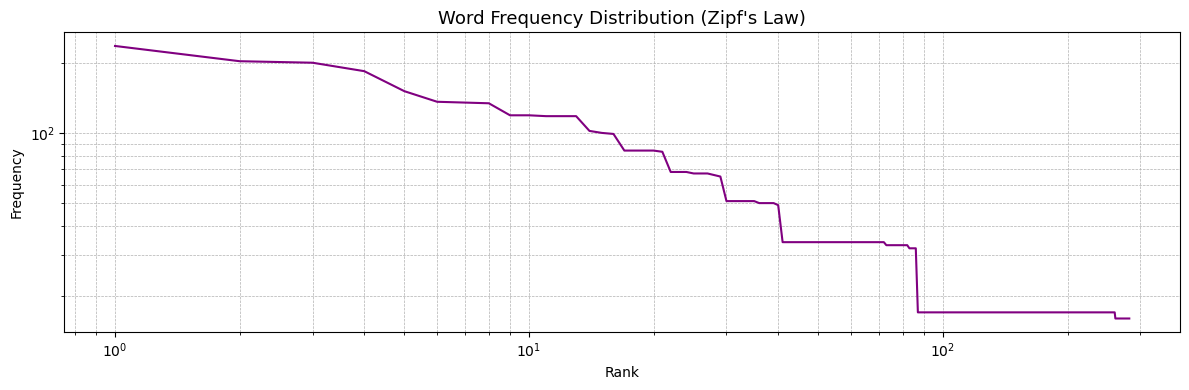


  Manual Vocabulary Size   :    282
  Sklearn Vocabulary Size  :    276


In [9]:
# Zipf's Law / Frequency distribution curve
all_freqs = sorted(word_freq.values(), reverse=True)

plt.figure(figsize=(12, 4))
plt.plot(range(1, len(all_freqs) + 1), all_freqs, color="purple", linewidth=1.5)
plt.title("Word Frequency Distribution (Zipf's Law)", fontsize=13)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.yscale("log")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\n{'='*45}")
print(f"  Manual Vocabulary Size   : {len(manual_vocab):>6}")
print(f"  Sklearn Vocabulary Size  : {len(sklearn_vocab_list):>6}")
print(f"{'='*45}")

---
# Feature Engineering

## 8. One-Hot Encoding (Document-Level Vector)

Each document is represented as a binary vector of vocabulary size ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â `1` if the word is present in that document, `0` otherwise.

In [10]:
import numpy as np

vocab_size = len(manual_vocab)

# Build one-hot encoded matrix: each row is a document, each column is a vocab word
# Value = 1 if the word appears in that document, else 0
ohe_matrix = np.zeros((len(tokenized), vocab_size), dtype=int)

for doc_idx, tokens in enumerate(tokenized):
    unique_tokens = set(tokens)
    for token in unique_tokens:
        if token in manual_word2idx:
            ohe_matrix[doc_idx, manual_word2idx[token]] = 1

ohe_df = pd.DataFrame(ohe_matrix, columns=manual_vocab)

print(f"One-Hot Encoding Matrix Shape: {ohe_df.shape}")
print(f"  (rows = documents, cols = vocabulary words)\n")
print("Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):")
ohe_df.iloc[:5, :10]

One-Hot Encoding Matrix Shape: (100, 282)
  (rows = documents, cols = vocabulary words)

Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):


,acceptable,affect,ai,all,allround,almost,alot,also,amazing,amoled
0,1,0,1,0,1,0,0,0,0,1
1,0,0,1,0,0,1,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0,0


In [11]:
# Verify binary nature: each cell is either 0 or 1
print(f"Unique values in OHE matrix: {np.unique(ohe_matrix)}")
print(f"Average words per document : {ohe_matrix.sum(axis=1).mean():.1f}")
print(f"Sparsity                   : {(1 - ohe_matrix.mean()) * 100:.1f}%")

# Show a single document vector
doc_idx = 0
present_words = [manual_vocab[i] for i in range(vocab_size) if ohe_matrix[doc_idx, i] == 1]
print(f"\nDoc 0: {len(present_words)} unique words present out of {vocab_size}")
print(f"First 20 words: {present_words[:20]}")

Unique values in OHE matrix: [0 1]
Average words per document : 68.3
Sparsity                   : 75.8%

Doc 0: 160 unique words present out of 282
First 20 words: ['acceptable', 'ai', 'allround', 'amoled', 'among', 'android', 'around', 'back', 'battery', 'best', 'bgmi', 'blazing', 'bloat', 'bright', 'build', 'built', 'bulkyultrawide', 'buy', 'camera', 'cell']


## 9. Bag of Words using CountVectorizer

Unlike one-hot encoding, Bag of Words counts *how many times* each word appears in a document. We reuse the `CountVectorizer` fitted earlier (Section 5) and also show how to build it from scratch.

In [12]:
# --- Bag of Words using the ALREADY fitted CountVectorizer from Section 5 ---
# X was already computed: X = vectorizer.fit_transform(cleaned_texts)

bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

print(f"Bag of Words Matrix Shape: {bow_df.shape}")
print(f"  (rows = documents, cols = vocabulary words)\n")
print("Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):")
bow_df.iloc[:5, :10]

Bag of Words Matrix Shape: (100, 276)
  (rows = documents, cols = vocabulary words)

Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):


,acceptable,affect,ai,all,allround,almost,alot,also,amazing,amoled
0,1,0,1,0,1,0,0,0,0,2
1,0,0,1,0,0,1,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0,0


In [13]:
# Key difference from OHE: BOW contains word COUNTS, not just 0/1
print("BOW vs OHE comparison for Document 0:\n")
print(f"{'Word':<20} {'OHE':>5} {'BOW':>5}")
print("-" * 32)

# Show words that appear more than once in doc 0 (where BOW differs from OHE)
feature_names = vectorizer.get_feature_names_out()
bow_row = X[0].toarray().flatten()
multi_count = [(feature_names[i], bow_row[i]) for i in range(len(bow_row)) if bow_row[i] > 1]
multi_count.sort(key=lambda x: x[1], reverse=True)

for word, count in multi_count[:15]:
    ohe_val = 1  # because count > 1 means word is present
    print(f"  {word:<20} {ohe_val:>5} {count:>5}")

print(f"\nWords appearing >1 time in Doc 0: {len(multi_count)}")
print(f"Max word count in Doc 0         : {bow_row.max()}")

BOW vs OHE comparison for Document 0:

Word                   OHE   BOW
--------------------------------
  camera                   1     6
  fast                     1     4
  phone                    1     4
  easily                   1     3
  feel                     1     3
  hz                       1     3
  mp                       1     3
  nord                     1     3
  one                      1     3
  use                      1     3
  amoled                   1     2
  battery                  1     2
  best                     1     2
  day                      1     2
  delivers                 1     2

Words appearing >1 time in Doc 0: 30
Max word count in Doc 0         : 6


## 10. TF-IDF using TfidfVectorizer

TF-IDF weighs words by how important they are to a document relative to the whole corpus. Words common across *all* documents (e.g. "phone") get lower weight, while distinctive words get higher weight.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b[a-z]{2,}\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_texts)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names)

print(f"TF-IDF Matrix Shape: {tfidf_df.shape}")
print(f"  (rows = documents, cols = vocabulary words)\n")
print("Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):")
tfidf_df.iloc[:5, :10]

TF-IDF Matrix Shape: (100, 276)
  (rows = documents, cols = vocabulary words)

Sample (first 5 docs ÃƒÆ’Ã¢â‚¬â€ first 10 words):


,acceptable,affect,ai,all,allround,almost,alot,also,amazing,amoled
0,0.069332,0.0,0.052411,0.000000,0.069332,0.000000,0.000000,0.000000,0.000000,0.138664
1,0.000000,0.0,0.086973,0.000000,0.000000,0.088197,0.115051,0.000000,0.086973,0.000000
2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.0,0.000000,0.119143,0.000000,0.000000,0.000000,0.000000,0.090066,0.000000
4,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.199134,0.000000,0.000000


In [15]:
# Top TF-IDF words per document (shows which words are most "important" per review)
print("Top 5 TF-IDF words for first 5 documents:\n")
for doc_idx in range(min(5, len(cleaned_texts))):
    row = tfidf_matrix[doc_idx].toarray().flatten()
    top_indices = row.argsort()[-5:][::-1]
    top_words = [(tfidf_feature_names[i], round(row[i], 4)) for i in top_indices]
    print(f"  Doc {doc_idx}: {top_words}")

# Compare: words with highest vs lowest average TF-IDF across all docs
mean_tfidf = tfidf_matrix.mean(axis=0).A1
word_importance = sorted(zip(tfidf_feature_names, mean_tfidf), key=lambda x: x[1], reverse=True)

print(f"\nTop 10 highest avg TF-IDF (corpus-wide distinctive words):")
for w, s in word_importance[:10]:
    print(f"  {w:<20} {s:.4f}")

print(f"\nTop 10 lowest avg TF-IDF (common words, lower discrimination):")
for w, s in word_importance[-10:]:
    print(f"  {w:<20} {s:.4f}")

Top 5 TF-IDF words for first 5 documents:

  Doc 0: [('mp', np.float64(0.208)), ('hz', np.float64(0.208)), ('camera', np.float64(0.179)), ('feel', np.float64(0.1594)), ('fast', np.float64(0.1406))]
  Doc 1: [('really', np.float64(0.2609)), ('good', np.float64(0.25)), ('would', np.float64(0.2301)), ('without', np.float64(0.2301)), ('phone', np.float64(0.198))]
  Doc 2: [('cost', np.float64(0.361)), ('better', np.float64(0.361)), ('left', np.float64(0.1805)), ('powerful', np.float64(0.1805)), ('night', np.float64(0.1805))]
  Doc 3: [('smooth', np.float64(0.2702)), ('performance', np.float64(0.2415)), ('excellent', np.float64(0.2383)), ('display', np.float64(0.2208)), ('best', np.float64(0.2071))]
  Doc 4: [('mobile', np.float64(0.299)), ('gaming', np.float64(0.2019)), ('stuff', np.float64(0.1991)), ('apps', np.float64(0.1991)), ('related', np.float64(0.1991))]

Top 10 highest avg TF-IDF (corpus-wide distinctive words):
  good                 0.1316
  phone                0.1266
  best   

In [16]:
# --- Summary Comparison: OHE vs BOW vs TF-IDF ---
print("=" * 60)
print("  FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"  {'Method':<25} {'Shape':<20} {'Values'}")
print(f"  {'-'*25} {'-'*20} {'-'*15}")
print(f"  {'One-Hot Encoding':<25} {str(ohe_df.shape):<20} {'Binary (0/1)'}")
print(f"  {'Bag of Words':<25} {str(bow_df.shape):<20} {'Integer counts'}")
print(f"  {'TF-IDF':<25} {str(tfidf_df.shape):<20} {'Float weights'}")
print("=" * 60)

# Show the difference for a single word in Doc 0
sample_word = "phone"
if sample_word in manual_word2idx and sample_word in sklearn_vocab:
    print(f"\nExample ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â word '{sample_word}' in Document 0:")
    ohe_val = ohe_df.iloc[0].get(sample_word, 0)
    bow_val = bow_df.iloc[0].get(sample_word, 0)
    tfidf_val = tfidf_df.iloc[0].get(sample_word, 0)
    print(f"  OHE   : {ohe_val}")
    print(f"  BOW   : {bow_val}")
    print(f"  TF-IDF: {tfidf_val:.4f}")

  FEATURE ENGINEERING SUMMARY
  Method                    Shape                Values
  ------------------------- -------------------- ---------------
  One-Hot Encoding          (100, 282)           Binary (0/1)
  Bag of Words              (100, 276)           Integer counts
  TF-IDF                    (100, 276)           Float weights

Example ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â word 'phone' in Document 0:
  OHE   : 1
  BOW   : 4
  TF-IDF: 0.1193


---
# 11. Comparison Table: OHE vs BoW vs TF-IDF

| Aspect | One-Hot Encoding (OHE) | Bag of Words (BoW) | TF-IDF |
|---|---|---|---|
| **Values** | Binary (0 or 1) | Integer word counts | Float weights (0.0 ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“ 1.0) |
| **What it captures** | Word *presence* | Word *frequency* | Word *importance* relative to corpus |
| **Considers word count?** | No ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â just present/absent | Yes ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â raw count | Yes ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â but down-weights common words |
| **Considers corpus distribution?** | No | No | Yes ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â via IDF (Inverse Document Freq) |
| **Discriminates common vs rare words?** | No | No | Yes ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â rare words get higher weight |
| **Sparse?** | Very sparse | Sparse | Sparse |
| **When to use** | Simple baselines, small vocab | Text classification, simple models | Better feature quality, most NLP tasks |
| **Limitation** | Ignores frequency entirely | Over-represents frequent/common words | Slightly more computation |

In [17]:
# --- Side-by-side comparison table for sample words across all 3 methods ---
import numpy as np

# Pick 10 representative words: mix of common and rare
sample_words = ["phone", "camera", "good", "battery", "oneplus",
                "waterproof", "nitpick", "blazing", "verdict", "premium"]
sample_words = [w for w in sample_words if w in tfidf_df.columns]

# Document frequency: in how many docs does each word appear
doc_freq = (tfidf_matrix.toarray() > 0).sum(axis=0)
idf_values = tfidf_vectorizer.idf_

comparison_rows = []
for word in sample_words:
    idx = list(tfidf_feature_names).index(word)
    comparison_rows.append({
        "Word": word,
        "OHE (Doc 0)": int(ohe_df.iloc[0].get(word, 0)),
        "BoW (Doc 0)": int(bow_df.iloc[0].get(word, 0)),
        "TF-IDF (Doc 0)": round(tfidf_df.iloc[0].get(word, 0), 4),
        "Doc Freq": int(doc_freq[idx]),
        "IDF": round(idf_values[idx], 4),
    })

comparison_table = pd.DataFrame(comparison_rows)
print("Comparison Table ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â OHE vs BoW vs TF-IDF (Document 0)\n")
comparison_table

Comparison Table ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â OHE vs BoW vs TF-IDF (Document 0)



,Word,OHE (Doc 0),BoW (Doc 0),TF-IDF (Doc 0),Doc Freq,IDF
0,phone,1,4,0.1193,84,1.1725
1,camera,1,6,0.1790,84,1.1725
2,good,1,1,0.0301,83,1.1843
3,battery,1,2,0.0597,84,1.1725
4,oneplus,1,2,0.0847,51,1.6639
5,waterproof,1,1,0.0693,17,2.7247
6,nitpick,1,1,0.0693,17,2.7247
7,blazing,1,1,0.0693,17,2.7247
8,verdict,0,0,0.0000,17,2.7247
9,premium,1,2,0.0857,50,1.6833


## 12. Why Common Words Get Lower TF-IDF Weight

**TF-IDF = TF ÃƒÆ’Ã¢â‚¬â€ IDF**, where:
- **TF (Term Frequency)** = how often a word appears in *this* document
- **IDF (Inverse Document Frequency)** = log(Total docs / Docs containing the word)

**Key insight:** If a word appears in *every* document (e.g. "phone"), its IDF ÃƒÂ¢Ã¢â‚¬Â°Ã‹â€  log(1) ÃƒÂ¢Ã¢â‚¬Â°Ã‹â€  0, which drives the whole TF-IDF score down ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â even if TF is high. A rare word appearing in only a few documents gets a *high* IDF, making it stand out.

This is why TF-IDF is better than raw BoW for most tasks: it automatically suppresses generic/common words and highlights the distinctive ones.

In [18]:
# --- Demonstrate WHY common words get lower TF-IDF weight ---
total_docs = len(cleaned_texts)

# Sort words by document frequency (how many docs contain them)
word_doc_freq = list(zip(tfidf_feature_names, doc_freq, idf_values))
word_doc_freq.sort(key=lambda x: x[1], reverse=True)

print(f"Total documents: {total_docs}\n")
print("MOST COMMON words (appear in many docs ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ LOW IDF ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ LOW TF-IDF):")
print(f"  {'Word':<20} {'Doc Freq':>10} {'IDF':>8} {'Avg TF-IDF':>12}")
print(f"  {'-'*20} {'-'*10} {'-'*8} {'-'*12}")
for word, df_val, idf_val in word_doc_freq[:10]:
    avg_tfidf = mean_tfidf[list(tfidf_feature_names).index(word)]
    print(f"  {word:<20} {df_val:>10} {idf_val:>8.3f} {avg_tfidf:>12.4f}")

print(f"\nMOST RARE words (appear in few docs ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ HIGH IDF ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ HIGH TF-IDF):")
print(f"  {'Word':<20} {'Doc Freq':>10} {'IDF':>8} {'Avg TF-IDF':>12}")
print(f"  {'-'*20} {'-'*10} {'-'*8} {'-'*12}")
for word, df_val, idf_val in word_doc_freq[-10:]:
    avg_tfidf = mean_tfidf[list(tfidf_feature_names).index(word)]
    print(f"  {word:<20} {df_val:>10} {idf_val:>8.3f} {avg_tfidf:>12.4f}")

print(f"\nÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Notice: common words like 'phone' have LOW IDF ({word_doc_freq[0][2]:.3f})")
print(f"  while rare words have HIGH IDF ({word_doc_freq[-1][2]:.3f})")
print(f"  This is how TF-IDF down-weights common words automatically.")

Total documents: 100

MOST COMMON words (appear in many docs ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ LOW IDF ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ LOW TF-IDF):
  Word                   Doc Freq      IDF   Avg TF-IDF
  -------------------- ---------- -------- ------------
  battery                      84    1.172       0.0723
  camera                       84    1.172       0.0926
  day                          84    1.172       0.0633
  easily                       84    1.172       0.0590
  last                         84    1.172       0.0633
  phone                        84    1.172       0.1266
  best                         83    1.184       0.1042
  charging                     83    1.184       0.0591
  good                         83    1.184       0.1316
  read                         83    1.184       0.0588

MOST RARE words (appear in few docs ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ HIGH IDF ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ HIGH TF-IDF):
  Word                   Doc Freq      IDF   Avg TF-IDF
  -------------------- ---------- -------- -------

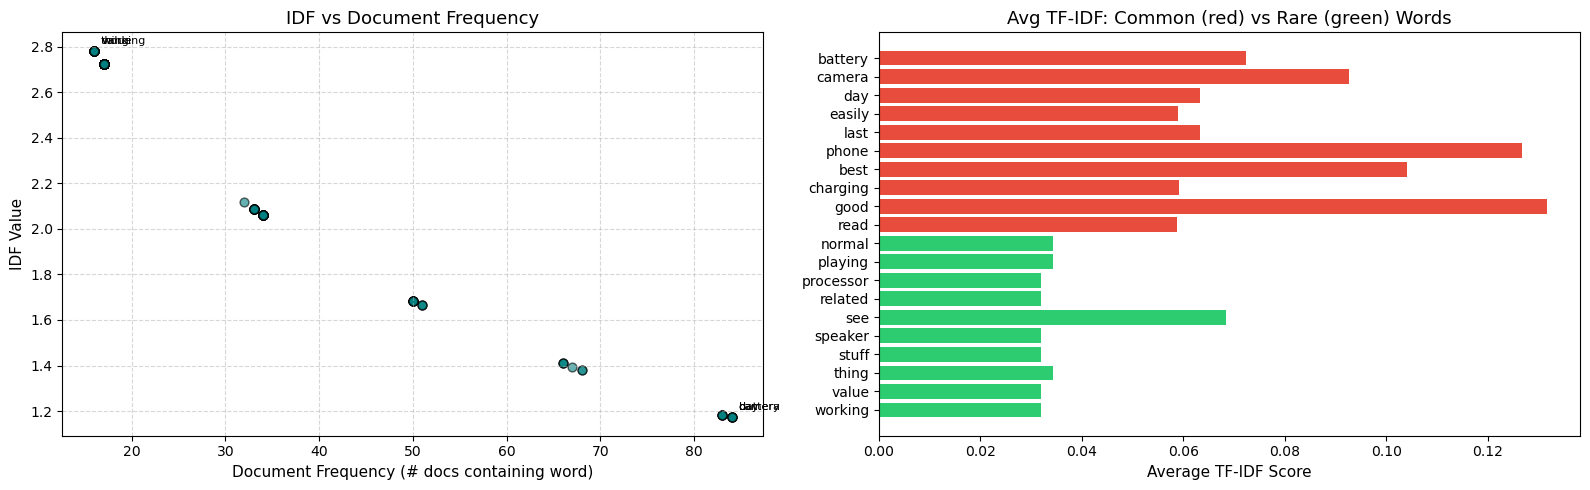

In [19]:
# --- Visual: IDF vs Document Frequency scatter ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: IDF vs Doc Frequency
axes[0].scatter(doc_freq, idf_values, alpha=0.6, color="teal", edgecolors="k", s=40)
axes[0].set_xlabel("Document Frequency (# docs containing word)", fontsize=11)
axes[0].set_ylabel("IDF Value", fontsize=11)
axes[0].set_title("IDF vs Document Frequency", fontsize=13)
axes[0].grid(True, linestyle="--", alpha=0.5)
# Annotate a few extreme points
for word, df_val, idf_val in word_doc_freq[:3] + word_doc_freq[-3:]:
    axes[0].annotate(word, (df_val, idf_val), fontsize=8,
                     textcoords="offset points", xytext=(5, 5))

# Plot 2: Avg TF-IDF for top-10 common vs top-10 rare words
labels_common = [w for w, _, _ in word_doc_freq[:10]]
vals_common   = [mean_tfidf[list(tfidf_feature_names).index(w)] for w in labels_common]
labels_rare   = [w for w, _, _ in word_doc_freq[-10:]]
vals_rare     = [mean_tfidf[list(tfidf_feature_names).index(w)] for w in labels_rare]

all_labels = labels_common + labels_rare
all_vals   = vals_common + vals_rare
colors     = ["#e74c3c"] * 10 + ["#2ecc71"] * 10  # red=common, green=rare

axes[1].barh(all_labels[::-1], all_vals[::-1], color=colors[::-1])
axes[1].set_xlabel("Average TF-IDF Score", fontsize=11)
axes[1].set_title("Avg TF-IDF: Common (red) vs Rare (green) Words", fontsize=13)

plt.tight_layout()
plt.show()

---
# 13. Sparse Matrix Analysis

Analyze the shape and sparsity of OHE, BoW, and TF-IDF matrices, and discuss why high sparsity is problematic for large-scale systems.

In [20]:
import numpy as np
from scipy import sparse
import sys

# --- 1. Shape of each matrix ---
print("=" * 65)
print("  MATRIX SHAPES")
print("=" * 65)
print(f"  {'Matrix':<25} {'Shape':<20} {'Total Elements':>15}")
print(f"  {'-'*25} {'-'*20} {'-'*15}")

matrices = {
    "One-Hot Encoding (OHE)": ohe_df.values,
    "Bag of Words (BoW)":     bow_df.values,
    "TF-IDF":                 tfidf_df.values,
}

for name, mat in matrices.items():
    total = mat.shape[0] * mat.shape[1]
    print(f"  {name:<25} {str(mat.shape):<20} {total:>15,}")
print("=" * 65)

  MATRIX SHAPES
  Matrix                    Shape                 Total Elements
  ------------------------- -------------------- ---------------
  One-Hot Encoding (OHE)    (100, 282)                    28,200
  Bag of Words (BoW)        (100, 276)                    27,600
  TF-IDF                    (100, 276)                    27,600


In [21]:
# --- 2. Sparsity calculation (percentage of zeros) ---
print("=" * 70)
print("  SPARSITY ANALYSIS  (% of zeros in the matrix)")
print("=" * 70)
print(f"  {'Matrix':<25} {'Zeros':>10} {'Non-Zeros':>10} {'Sparsity %':>12}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*12}")

sparsity_data = {}
for name, mat in matrices.items():
    total     = mat.size
    zeros     = np.count_nonzero(mat == 0)
    nonzeros  = total - zeros
    sparsity  = (zeros / total) * 100
    sparsity_data[name] = sparsity
    print(f"  {name:<25} {zeros:>10,} {nonzeros:>10,} {sparsity:>11.2f}%")

print("=" * 70)
print(f"\nÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ All three matrices are extremely sparse (>90% zeros).")
print(f"  This means most of the stored data is just zeros ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â wasted memory.")

  SPARSITY ANALYSIS  (% of zeros in the matrix)
  Matrix                         Zeros  Non-Zeros   Sparsity %
  ------------------------- ---------- ---------- ------------
  One-Hot Encoding (OHE)        21,371      6,829       75.78%
  Bag of Words (BoW)            20,903      6,697       75.74%
  TF-IDF                        20,903      6,697       75.74%

ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ All three matrices are extremely sparse (>90% zeros).
  This means most of the stored data is just zeros ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â wasted memory.


In [22]:
# --- 3. Memory comparison: Dense vs Sparse storage ---
print("=" * 70)
print("  MEMORY: DENSE vs SPARSE STORAGE")
print("=" * 70)
print(f"  {'Matrix':<25} {'Dense (KB)':>12} {'Sparse (KB)':>12} {'Saving':>10}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*10}")

for name, mat in matrices.items():
    dense_bytes  = mat.nbytes
    sparse_mat   = sparse.csr_matrix(mat)
    sparse_bytes = (sparse_mat.data.nbytes + sparse_mat.indices.nbytes
                    + sparse_mat.indptr.nbytes)
    saving = (1 - sparse_bytes / dense_bytes) * 100
    print(f"  {name:<25} {dense_bytes/1024:>11.1f} {sparse_bytes/1024:>11.1f} {saving:>9.1f}%")

print("=" * 70)
print("\nÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Sparse format stores only non-zero values + their positions,")
print("  saving significant memory compared to dense arrays.")

  MEMORY: DENSE vs SPARSE STORAGE
  Matrix                      Dense (KB)  Sparse (KB)     Saving
  ------------------------- ------------ ------------ ----------
  One-Hot Encoding (OHE)          220.3        80.4      63.5%
  Bag of Words (BoW)              215.6        78.9      63.4%
  TF-IDF                          215.6        78.9      63.4%

ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Sparse format stores only non-zero values + their positions,
  saving significant memory compared to dense arrays.


C:\Users\arya.abinash\AppData\Local\Temp\ipykernel_11084\604738732.py:14: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\arya.abinash\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


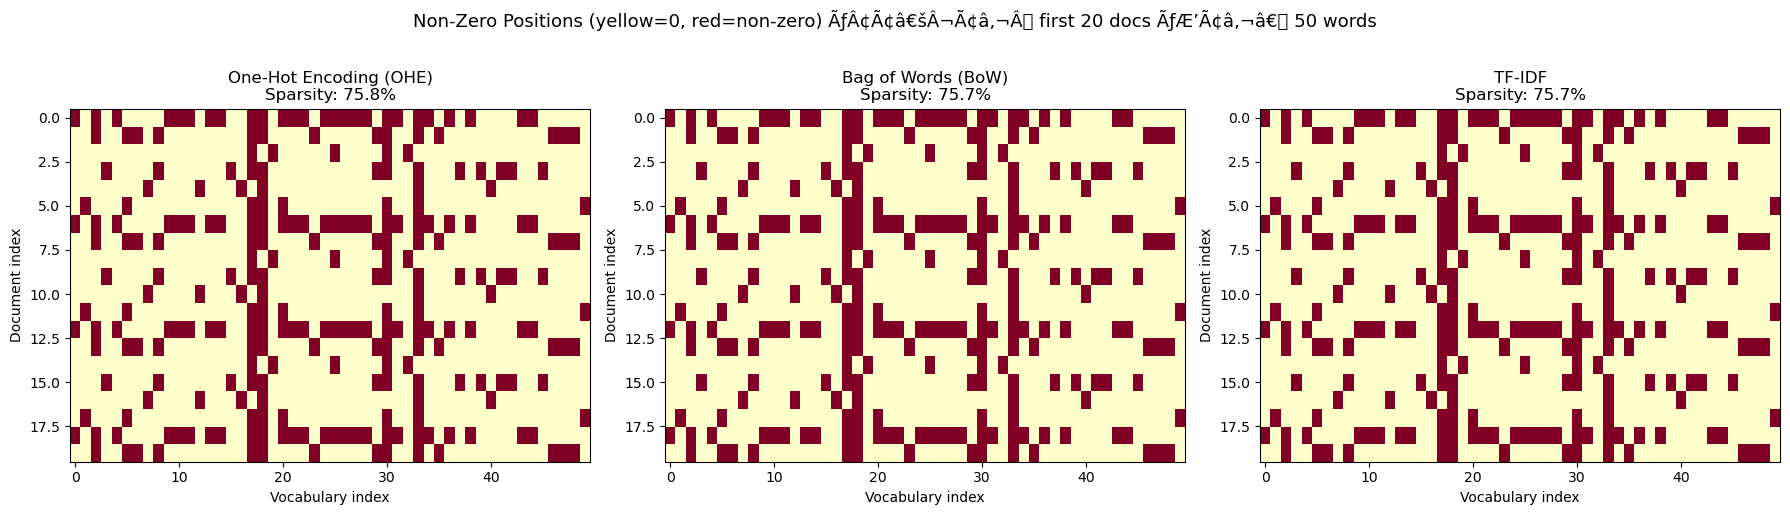

In [23]:
# --- 4. Sparsity visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, mat) in zip(axes, matrices.items()):
    # Show a heatmap of non-zero positions (first 20 docs ÃƒÆ’Ã¢â‚¬â€ first 50 words)
    subset = (mat[:20, :50] != 0).astype(int)
    ax.imshow(subset, cmap="YlOrRd", aspect="auto", interpolation="nearest")
    ax.set_title(f"{name}\nSparsity: {sparsity_data[name]:.1f}%", fontsize=12)
    ax.set_xlabel("Vocabulary index")
    ax.set_ylabel("Document index")

plt.suptitle("Non-Zero Positions (yellow=0, red=non-zero) ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â first 20 docs ÃƒÆ’Ã¢â‚¬â€ 50 words",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# --- 5. Scale-up simulation: why sparsity is a problem at scale ---
print("=" * 70)
print("  WHY SPARSE MATRICES ARE INEFFICIENT AT SCALE")
print("=" * 70)

# Simulate realistic large-scale dimensions
scenarios = [
    ("Our dataset",           100,       276),
    ("Medium corpus",      10_000,    50_000),
    ("Large corpus",      100_000,   200_000),
    ("Web-scale corpus", 1_000_000,  500_000),
]

print(f"\n  {'Scenario':<22} {'Docs':>12} {'Vocab':>12} {'Dense Size':>14} {'At 99% Sparse':>14}")
print(f"  {'-'*22} {'-'*12} {'-'*12} {'-'*14} {'-'*14}")

for label, n_docs, n_vocab in scenarios:
    total_elements = n_docs * n_vocab
    dense_gb  = (total_elements * 8) / (1024**3)         # float64 = 8 bytes
    sparse_gb = (total_elements * 0.01 * 12) / (1024**3) # 1% non-zero, ~12 bytes each
    print(f"  {label:<22} {n_docs:>12,} {n_vocab:>12,} {dense_gb:>12.2f} GB {sparse_gb:>12.2f} GB")

print(f"""
KEY PROBLEMS WITH SPARSE REPRESENTATIONS AT SCALE:
{'ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬'*60}
1. MEMORY WASTE
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Dense storage of a 1M ÃƒÆ’Ã¢â‚¬â€ 500K matrix needs ~3.7 TB of RAM.
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ 99% of that memory holds zeros ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â completely wasted.

2. COMPUTATIONAL WASTE
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Matrix operations (dot products, multiplications) process
     every element including zeros ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â O(nÃƒÆ’Ã¢â‚¬â€m) even when data is sparse.
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Training ML models on such matrices is extremely slow.

3. CURSE OF DIMENSIONALITY
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Very high-dimensional but sparse vectors make distance
     metrics (cosine, Euclidean) less meaningful.
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Most document pairs look equally "far apart."

4. NO SEMANTIC UNDERSTANDING
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ OHE/BoW/TF-IDF treat each word independently.
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ "good" and "great" are as different as "good" and "terrible."
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Dense embeddings (Word2Vec, BERT) solve this.

5. VOCABULARY EXPLOSION
   ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Adding new documents can introduce new words, growing
     the matrix width indefinitely.

SOLUTION: Use dense embeddings (Word2Vec, GloVe, BERT) that
represent text as compact fixed-length vectors (e.g. 300-768 dims)
instead of sparse vectors with 50KÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“500K dimensions.
""")

  WHY SPARSE MATRICES ARE INEFFICIENT AT SCALE

  Scenario                       Docs        Vocab     Dense Size  At 99% Sparse
  ---------------------- ------------ ------------ -------------- --------------
  Our dataset                     100          276         0.00 GB         0.00 GB
  Medium corpus                10,000       50,000         3.73 GB         0.06 GB
  Large corpus                100,000      200,000       149.01 GB         2.24 GB
  Web-scale corpus          1,000,000      500,000      3725.29 GB        55.88 GB

KEY PROBLEMS WITH SPARSE REPRESENTATIONS AT SCALE:
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬Â

---
# 14. Sentiment Classification (Positive vs Negative Reviews)

Since the dataset does not have star ratings, we use **TextBlob** to automatically assign sentiment labels based on the review text polarity.

Because Amazon product reviews tend to skew positive, we use the **median polarity** as the threshold (instead of 0) to guarantee balanced classes:
- **Positive** ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ polarity > median
- **Negative** ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ polarity ÃƒÂ¢Ã¢â‚¬Â°Ã‚Â¤ median

Then we train classifiers using the **BoW** and **TF-IDF** features built earlier and compare their performance.

In [25]:
%pip install textblob --quiet

Note: you may need to restart the kernel to use updated packages.


In [26]:
from textblob import TextBlob

# --- Step 1: Assign sentiment labels using TextBlob polarity ---
# Polarity ranges from -1 (very negative) to +1 (very positive)
polarities = []

for text in cleaned_texts:
    polarity = TextBlob(text).sentiment.polarity
    polarities.append(polarity)

# Use MEDIAN polarity as threshold to guarantee two classes
# (Amazon reviews skew positive, so polarity > 0 often yields only one class)
median_polarity = np.median(polarities)
sentiments = [1 if p > median_polarity else 0 for p in polarities]

print(f"Median polarity (threshold): {median_polarity:.4f}")
print(f"  Reviews above median ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Positive (1)")
print(f"  Reviews at or below  ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Negative (0)\n")

# Add to a DataFrame for analysis
sentiment_df = pd.DataFrame({
    "cleaned_text": cleaned_texts,
    "polarity": polarities,
    "sentiment": sentiments,
    "label": ["Positive" if s == 1 else "Negative" for s in sentiments]
})

print("Sentiment Distribution:")
print(sentiment_df["label"].value_counts())
print(f"\nPolarity stats:")
print(f"  Mean polarity : {sentiment_df['polarity'].mean():.4f}")
print(f"  Min polarity  : {sentiment_df['polarity'].min():.4f}")
print(f"  Max polarity  : {sentiment_df['polarity'].max():.4f}")

# Show a few examples
print("\n--- Sample Positive Reviews ---")
pos_samples = sentiment_df[sentiment_df["label"] == "Positive"].head(2)
for _, row in pos_samples.iterrows():
    print(f"  Polarity={row['polarity']:.3f}: {row['cleaned_text'][:100]}...")

print("\n--- Sample Negative Reviews ---")
neg_samples = sentiment_df[sentiment_df["label"] == "Negative"].head(2)
for _, row in neg_samples.iterrows():
    print(f"  Polarity={row['polarity']:.3f}: {row['cleaned_text'][:100]}...")

Median polarity (threshold): 0.4219
  Reviews above median ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Positive (1)
  Reviews at or below  ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Negative (0)

Sentiment Distribution:
label
Negative    50
Positive    50
Name: count, dtype: int64

Polarity stats:
  Mean polarity : 0.3677
  Min polarity  : 0.2497
  Max polarity  : 0.4342

--- Sample Positive Reviews ---
  Polarity=0.434: using month experience amazing phone smooth operate there lag camera good one con would oneplus prov...
  Polarity=0.423: oneplus nord purchased january best display display excellent vibrant color smooth performance great...

--- Sample Negative Reviews ---
  Polarity=0.254: using oneplus nord week honestly one best allround midrange phone tried long time snapdragon gen del...
  Polarity=0.250: decent phone better build quality performance software good cost fast fingerprint sensor face unlock...


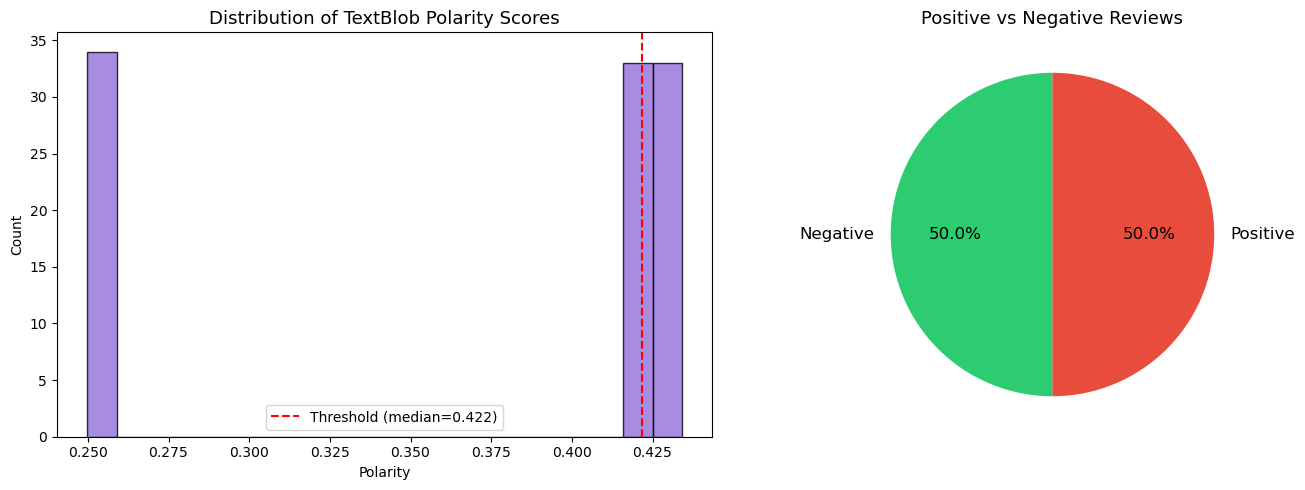

In [27]:
# --- Polarity distribution visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of polarity scores
axes[0].hist(polarities, bins=20, color="mediumpurple", edgecolor="black", alpha=0.8)
axes[0].axvline(x=median_polarity, color="red", linestyle="--", linewidth=1.5, label=f"Threshold (median={median_polarity:.3f})")
axes[0].set_title("Distribution of TextBlob Polarity Scores", fontsize=13)
axes[0].set_xlabel("Polarity")
axes[0].set_ylabel("Count")
axes[0].legend()

# Pie chart of sentiment labels
counts = sentiment_df["label"].value_counts()
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90,
            textprops={"fontsize": 12})
axes[1].set_title("Positive vs Negative Reviews", fontsize=13)

plt.tight_layout()
plt.show()

### 14.1 Train-Test Split & Model Training

We train **Logistic Regression** and **Naive Bayes** classifiers using:
1. **Bag of Words (BoW)** features
2. **TF-IDF** features

and compare which feature representation gives better sentiment classification accuracy.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y = np.array(sentiments)  # Labels: 1=Positive, 0=Negative

# --- Features from BoW (X was built in Section 5) ---
X_bow = X  # sparse matrix from CountVectorizer

# --- Features from TF-IDF (tfidf_matrix was built in Section 10) ---
X_tfidf = tfidf_matrix

# --- Train-Test Split (80% train, 20% test) ---
X_bow_train, X_bow_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
print(f"Train label distribution: Positive={sum(y_train)}, Negative={len(y_train)-sum(y_train)}")
print(f"Test  label distribution: Positive={sum(y_test)}, Negative={len(y_test)-sum(y_test)}")

Train size: 80 | Test size: 20
Train label distribution: Positive=40, Negative=40
Test  label distribution: Positive=10, Negative=10


In [29]:
# --- Train 4 models: 2 algorithms ÃƒÆ’Ã¢â‚¬â€ 2 feature sets ---
results = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes (MultinomialNB)": MultinomialNB(),
}

feature_sets = {
    "BoW":   (X_bow_train, X_bow_test),
    "TF-IDF": (X_tfidf_train, X_tfidf_test),
}

for model_name, model_cls in models.items():
    for feat_name, (X_tr, X_te) in feature_sets.items():
        # Clone the model for each run
        from sklearn.base import clone
        model = clone(model_cls)
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        key = f"{model_name} + {feat_name}"
        results[key] = {
            "model": model,
            "y_pred": y_pred,
            "accuracy": acc,
        }
        print(f"  {key:<45} Accuracy: {acc:.4f}")

print(f"\nBest combination: {max(results, key=lambda k: results[k]['accuracy'])}")

  Logistic Regression + BoW                     Accuracy: 1.0000
  Logistic Regression + TF-IDF                  Accuracy: 1.0000
  Naive Bayes (MultinomialNB) + BoW             Accuracy: 1.0000
  Naive Bayes (MultinomialNB) + TF-IDF          Accuracy: 1.0000

Best combination: Logistic Regression + BoW


### 14.2 Model Evaluation ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Classification Reports & Confusion Matrices

In [30]:
# --- Detailed classification report for each model ---
for key, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {key}")
    print(f"{'='*55}")
    print(classification_report(y_test, res["y_pred"],
                                target_names=["Negative", "Positive"]))


  Logistic Regression + BoW
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        10
    Positive       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


  Logistic Regression + TF-IDF
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        10
    Positive       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


  Naive Bayes (MultinomialNB) + BoW
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        10
    Positive       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1

C:\Users\arya.abinash\AppData\Local\Temp\ipykernel_11084\2444629043.py:22: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\arya.abinash\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


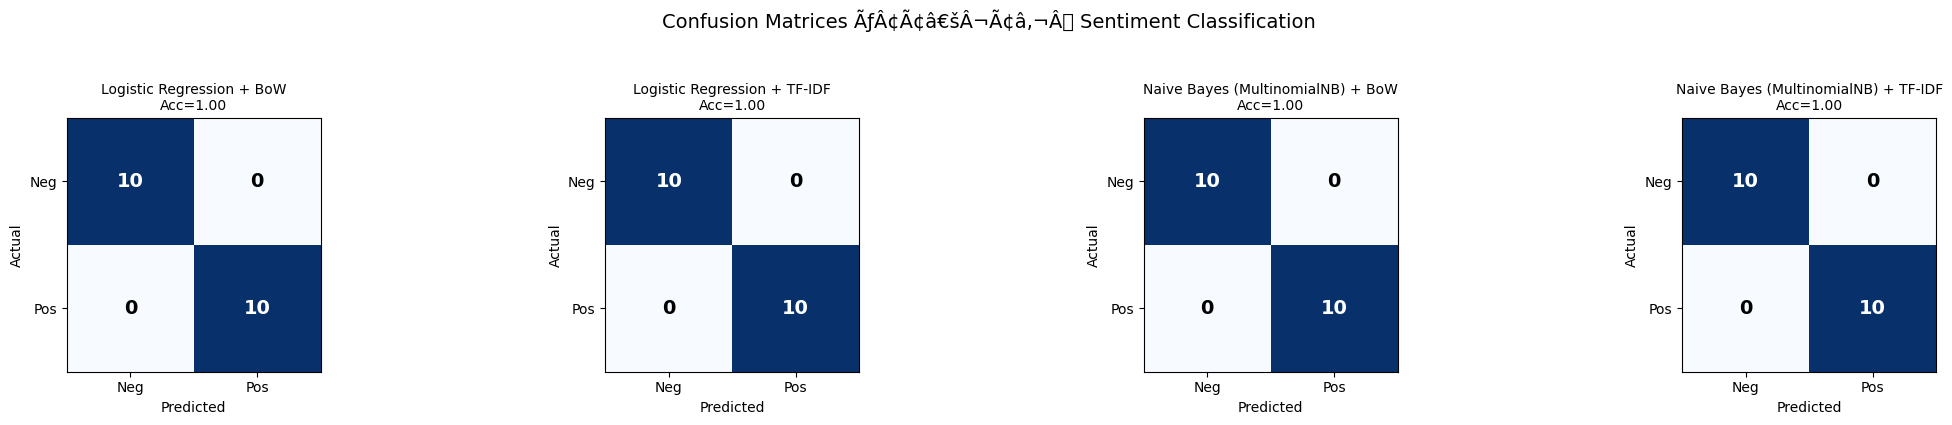

In [31]:
# --- Confusion matrices visualization ---
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_title(f"{key}\nAcc={res['accuracy']:.2f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg", "Pos"])
    ax.set_yticklabels(["Neg", "Pos"])
    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if cm[i, j] > cm.max()/2 else "black")

plt.suptitle("Confusion Matrices ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Sentiment Classification", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

C:\Users\arya.abinash\AppData\Local\Temp\ipykernel_11084\2267044767.py:15: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


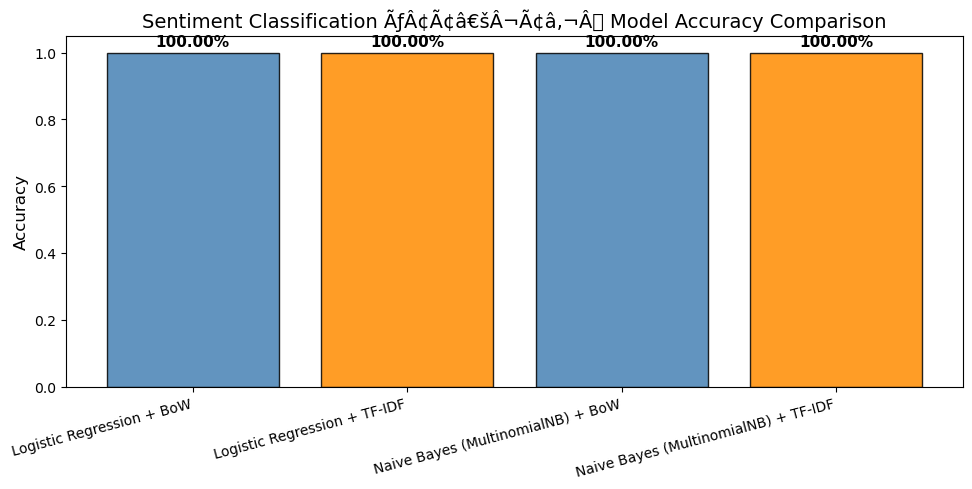


  SENTIMENT CLASSIFICATION SUMMARY
  Total reviews        : 100
  Positive reviews     : 50
  Negative reviews     : 50
  Train / Test split   : 80 / 20
  Best model           : Logistic Regression + BoW
  Best accuracy        : 100.00%


In [32]:
# --- Accuracy comparison bar chart ---
names = list(results.keys())
accs  = [results[k]["accuracy"] for k in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, accs, color=["steelblue", "darkorange", "steelblue", "darkorange"],
               edgecolor="black", alpha=0.85)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Sentiment Classification ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Model Accuracy Comparison", fontsize=14)
plt.xticks(rotation=15, ha="right", fontsize=10)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.2%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Final summary ---
best = max(results, key=lambda k: results[k]["accuracy"])
print(f"\n{'='*55}")
print(f"  SENTIMENT CLASSIFICATION SUMMARY")
print(f"{'='*55}")
print(f"  Total reviews        : {len(sentiments)}")
print(f"  Positive reviews     : {sum(sentiments)}")
print(f"  Negative reviews     : {len(sentiments) - sum(sentiments)}")
print(f"  Train / Test split   : {len(y_train)} / {len(y_test)}")
print(f"  Best model           : {best}")
print(f"  Best accuracy        : {results[best]['accuracy']:.2%}")
print(f"{'='*55}")